# RANDOM FOREST



In [ ]:
# Instala o uv (caso não esteja instalado no ambiente base)
%pip install uv
# Cria o ambiente virtual (.venv) no diretório atual e força a substituição se já existir
!uv venv --clear # Você pode desabilitar essa linha se já tiver o .venv no projeto. 
# Instala ESTRITAMENTE as bibliotecas usadas neste pipeline enxuto e o ipykernel
!uv pip install pandas numpy matplotlib scikit-learn ipykernel
# Conecta o kernel gerado para que o VS Code/Jupyter reconheça a máquina virtual
!uv run python -m ipykernel install --user --name aula-01 --display-name "random-forest(uv)"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Using CPython 3.13.9
Creating virtual environment at: .venv
Activate with: source .venv/bin/activate
Resolved 42 packages in 301ms                                        
Installed 42 packages in 357ms                              
 + asttokens==3.0.1
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.20
 + decorator==5.2.1
 + executing==2.2.1
 + fonttools==4.62.1
 + ipykernel==7.2.0
 + ipython==9.12.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + joblib==1.5.3
 + jupyter-client==8.8.0
 + jupyter-core==5.9.1
 + kiwisolver==1.5.0
 + matplotlib==3.10.8
 + matplotlib-inline==0.2.1
 + nest-asyncio==1.6.0
 + numpy==2.4.4
 + packaging==26.1
 + pandas==3.0.2
 + parso==0.8.6
 + pexpect==4.9.0
 + pillow==12.2.0
 + platformdirs==4.9.6
 + prompt-toolkit==3.0.52
 + psutil==7.2.2
 + ptyprocess==0.7.0
 + pure-eval==0.2.3
 + pygments=

## Após a execucao da 1a. celula:
- Voce deve pressionar CTRL+SHIT+P e executar "Developer:Reload Window" para selecionar o ambiente virtual recem criado: "random-forest(uv)". 
- A execucao das proximas celulas depende disso.

In [32]:
# Importando os pacotes necessários

import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import time

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# Carregando nosso Dataset e visualizando as primeiras linhas
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Quantidade de linhas e colunas do arquivo
df.shape

(20640, 10)

In [17]:
# Separando as variáveis preditoras e variavel target
# Retirei  `ocean_proximity`, pois só tem texto e `median_house_value` que é o target
preditoras = df.drop(['median_house_value','ocean_proximity'], axis = 1)
target = df['median_house_value']

In [5]:
# Visualiznado as variaveis preditoras
preditoras.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462


In [20]:
# Visualizando a variavel target
target.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [ ]:
# Separando os dados em Treino (0.7) e Teste (0.3)
x_treino, x_teste, y_treino, y_teste = train_test_split(preditoras, target, test_size = 0.3, random_state = 42)

In [8]:
# Quantidade dos dados de treino
x_treino.shape

(14448, 8)

In [21]:
# Criando uma arvore de decisão simples

# Criando o modelo
arvore = DecisionTreeRegressor()

# Treinando o modelo
arvore.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvore.predict(x_teste)

# Visualizando MSE
np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(70483.58938016351)

## Considerações Importantes 

<p>Quanto mais profunda a arvore, mais  propicia ela será ao overfiting, pois a arvore irá tentar achar sempre o split numa variavel que reduza mais a impureza dos nós (reduza os erros).

Imagine um situacao fictícia onde eu tenho 10 indivíduos com as seguintes características: (nome, cpf, tempo_servico, salario, valor_emprestimo, possui_divida, possui_casa_propria, quantidade_filhos, data_nascimento, target_bom_pagador). Dentro deste contexto, `target_bom_pagador` é a nossa variável alvo. Suponha agora, que dos 10 indivíduos, 30% são mal pagadores. Nosso objetivo, é criar um modelo de ML que permita indentificar novos individuos como bons ou mal pagadores afim de reduzirmos o  prejuizos em novos empréstimos bancários.  Dentro deste contexto, uma árvore de decisao funciona como uma ferramenta que tenta dividir os individuos tomando como base, as features disponíveis. Por exemplo, poderíamos criar uma árvore de decisao que divida os indivíduos em 2 grupos, aqueles que possuem salario acima de 10K e aqueles que possuem salario abaixo. Esse processo de divisao poderia continuar até o momento em que nao haveriam mais individuos para serem analisados. Neste caso, nosso processo causa o que chamamos de overfititng. 

In [29]:
# Vamos compreender melhor tudo isso

# Criando uma arvore com 1 nó de profundidade
arvore = DecisionTreeRegressor(max_depth = 1)

# Treinando o modelo
arvore.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvore.predict(x_teste)

# Visualizando o MSE
np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(95888.46721427873)

[Text(0.5, 0.75, 'median_income <= 5.032\nsquared_error = 13396959774.719\nsamples = 14448\nvalue = 206923.961'),
 Text(0.25, 0.25, 'squared_error = 8347041372.113\nsamples = 11340\nvalue = 172966.3'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 12263894213.433\nsamples = 3108\nvalue = 330823.533'),
 Text(0.625, 0.5, '  False')]

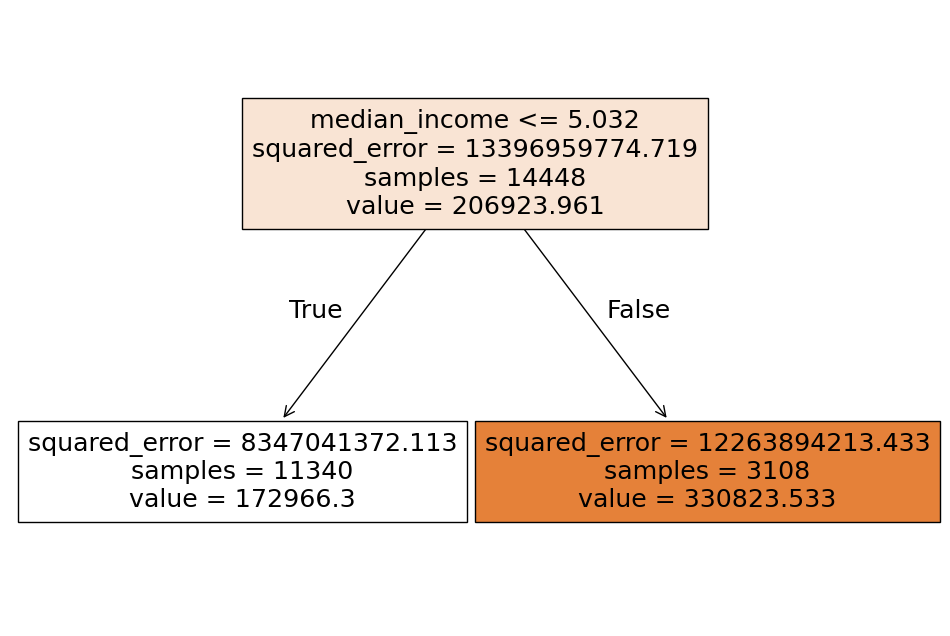

In [33]:
# Visualizando a arvore
plt.figure(figsize=(12,8))
plot_tree(arvore, feature_names = x_treino.columns, filled = True)

In [34]:
# Criando uma arvore com 2 nós de profundidade
arvore = DecisionTreeRegressor(max_depth = 2)

# Treinando o modelo
arvore.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvore.predict(x_teste)

# Visualizando o MSE
np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(85788.46356430463)

[Text(0.5, 0.8333333333333334, 'median_income <= 5.032\nsquared_error = 13396959774.719\nsamples = 14448\nvalue = 206923.961'),
 Text(0.25, 0.5, 'median_income <= 3.074\nsquared_error = 8347041372.113\nsamples = 11340\nvalue = 172966.3'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 5648845764.928\nsamples = 5490\nvalue = 135562.281'),
 Text(0.375, 0.16666666666666666, 'squared_error = 8334062795.122\nsamples = 5850\nvalue = 208068.534'),
 Text(0.75, 0.5, 'median_income <= 6.868\nsquared_error = 12263894213.433\nsamples = 3108\nvalue = 330823.533'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 9035888579.764\nsamples = 2201\nvalue = 291805.786'),
 Text(0.875, 0.16666666666666666, 'squared_error = 7437901254.397\nsamples = 907\nvalue = 425507.173')]

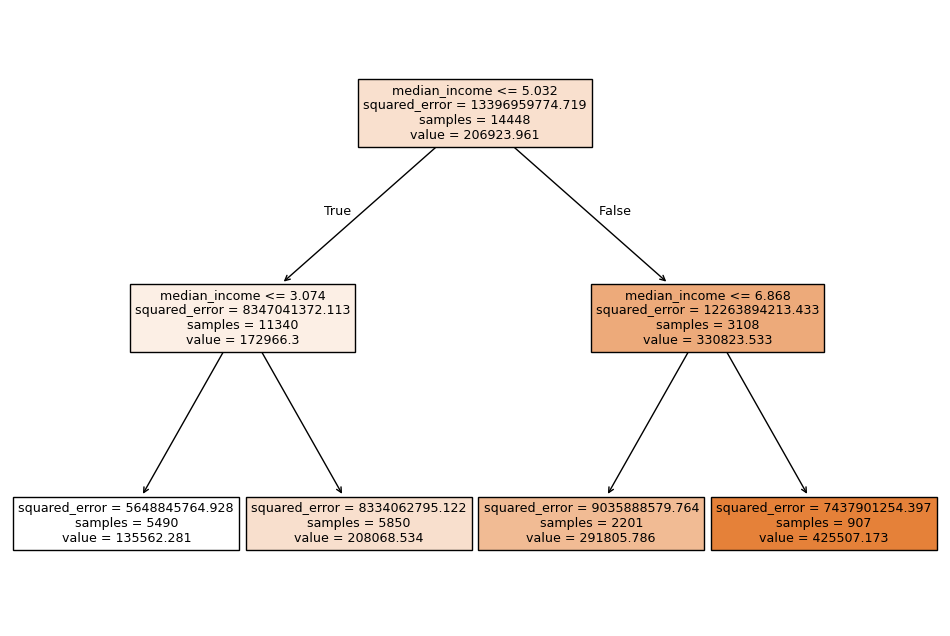

In [35]:
# Visualizando a arvore
plt.figure(figsize=(12,8))
plot_tree(arvore, feature_names = x_treino.columns, filled = True)

In [ ]:
# Criando uma arvore com 2 nós de profundidade
arvore = DecisionTreeRegressor(max_depth = 3)

# Treinando o modelo
arvore.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvore.predict(x_teste)

# Visualizando o MSE
np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(81989.87432066149)

[Text(0.5, 0.875, 'median_income <= 5.032\nsquared_error = 13396959774.719\nsamples = 14448\nvalue = 206923.961'),
 Text(0.25, 0.625, 'median_income <= 3.074\nsquared_error = 8347041372.113\nsamples = 11340\nvalue = 172966.3'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'latitude <= 34.455\nsquared_error = 5648845764.928\nsamples = 5490\nvalue = 135562.281'),
 Text(0.0625, 0.125, 'squared_error = 5604831866.304\nsamples = 2643\nvalue = 157119.076'),
 Text(0.1875, 0.125, 'squared_error = 4857821548.918\nsamples = 2847\nvalue = 115550.125'),
 Text(0.375, 0.375, 'housing_median_age <= 38.5\nsquared_error = 8334062795.122\nsamples = 5850\nvalue = 208068.534'),
 Text(0.3125, 0.125, 'squared_error = 6777914932.832\nsamples = 4642\nvalue = 195598.375'),
 Text(0.4375, 0.125, 'squared_error = 11420078818.133\nsamples = 1208\nvalue = 255987.801'),
 Text(0.75, 0.625, 'median_income <= 6.868\nsquared_error = 12263894213.433\nsamples = 3108\nvalue = 330823.533'),
 Text(0.625, 0.75, '  False'

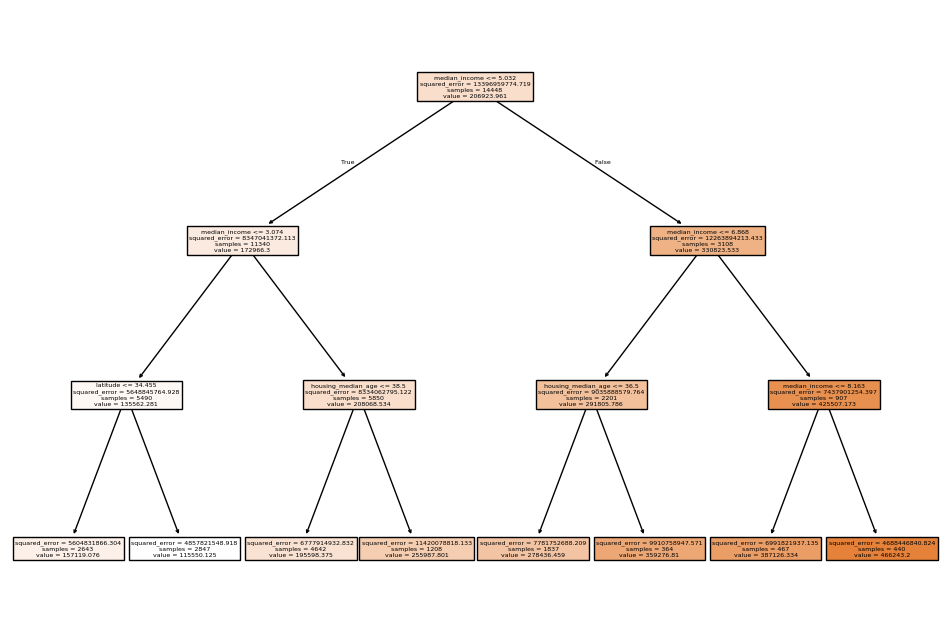

In [37]:
# Visualizando a arvore
plt.figure(figsize=(12,8))
plot_tree(arvore, feature_names = x_treino.columns, filled = True)

# Agora vamos entender o Random Forest...

In [ ]:
# Criando o algoritmo - O default são 100 árvores - apenas o hiperparâmetro random_state será usado
arvores = RandomForestRegressor(random_state = 42)

# Treinando o algoritmo
inicio = time.time()
arvores.fit(x_treino, y_treino)
fim = time.time()

# Gerando as previsões
previsao = arvores.predict(x_teste)

# Visualizando o MSE
print('Valor do MSE: ', np.sqrt(mean_squared_error(y_teste, previsao)))
print('Tempo de treino do modelo: ', fim - inicio)

# Observe que o resultado obtido (49745.23) é bem melhor do que o de uma DecisionTree.

Valor do MSE:  49745.233888767725
Tempo de treino do modelo:  7.257717132568359


In [40]:
# Criando o algoritmo utilizando o parametro n_jobs. 
# n_jobs ajusta automaticamente para o maximo de nucleos do processador.
arvores = RandomForestRegressor(random_state = 42, n_jobs = -1) 

# Treinando o algoritmo
inicio = time.time()
arvores.fit(x_treino, y_treino)
fim = time.time()

# Gerando as previsões
previsao = arvores.predict(x_teste)

# Visualizando o MSE
print('Valor do MSE: ', np.sqrt(mean_squared_error(y_teste, previsao)))
print('Tempo de treino do modelo: ', fim - inicio)

Valor do MSE:  49745.233888767725
Tempo de treino do modelo:  6.307136058807373


In [42]:
# Criar um modelo com 2 nós em cada arvore e utilizando 300 arvores

# Criando o modelo
arvores = RandomForestRegressor(n_estimators = 300, random_state = 42, n_jobs = -1)

# Treinando o modelo
arvores.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvores.predict(x_teste)

# Visualizando o MSE
np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(49533.41019171533)

In [46]:
# Criar um modelo com 5 nós em cada arvore e utilizando 300 arvores

# Criando o modelo
arvores = RandomForestRegressor(n_estimators = 300, max_depth = 2, random_state = 42, n_jobs = -1)

# Treinando o modelo
arvores.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvores.predict(x_teste)

# Visualizando o MSE
np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(84742.95459408364)

In [48]:
# Criar um modelo com 15 nós em cada arvore e utilizando 300 arvores

# Criando o modelo
arvores = RandomForestRegressor(n_estimators = 300, max_depth = 20, random_state = 42, n_jobs = -1)

# Treinando o modelo
arvores.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvores.predict(x_teste)

# Visualizando o MSE
np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(49595.91247195645)

# Vamos visualizar e entender o funcionamento do Random Forest

In [49]:
# Criar um modelo com 2 nós em cada arvore e utilizando 5 arvores

# Criando o modelo
arvores = RandomForestRegressor(n_estimators = 5, max_depth = 2, random_state = 42, n_jobs = -1)

# Treinando o modelo
arvores.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvores.predict(x_teste)

# Visualizando o MSE
np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(84978.86678466659)

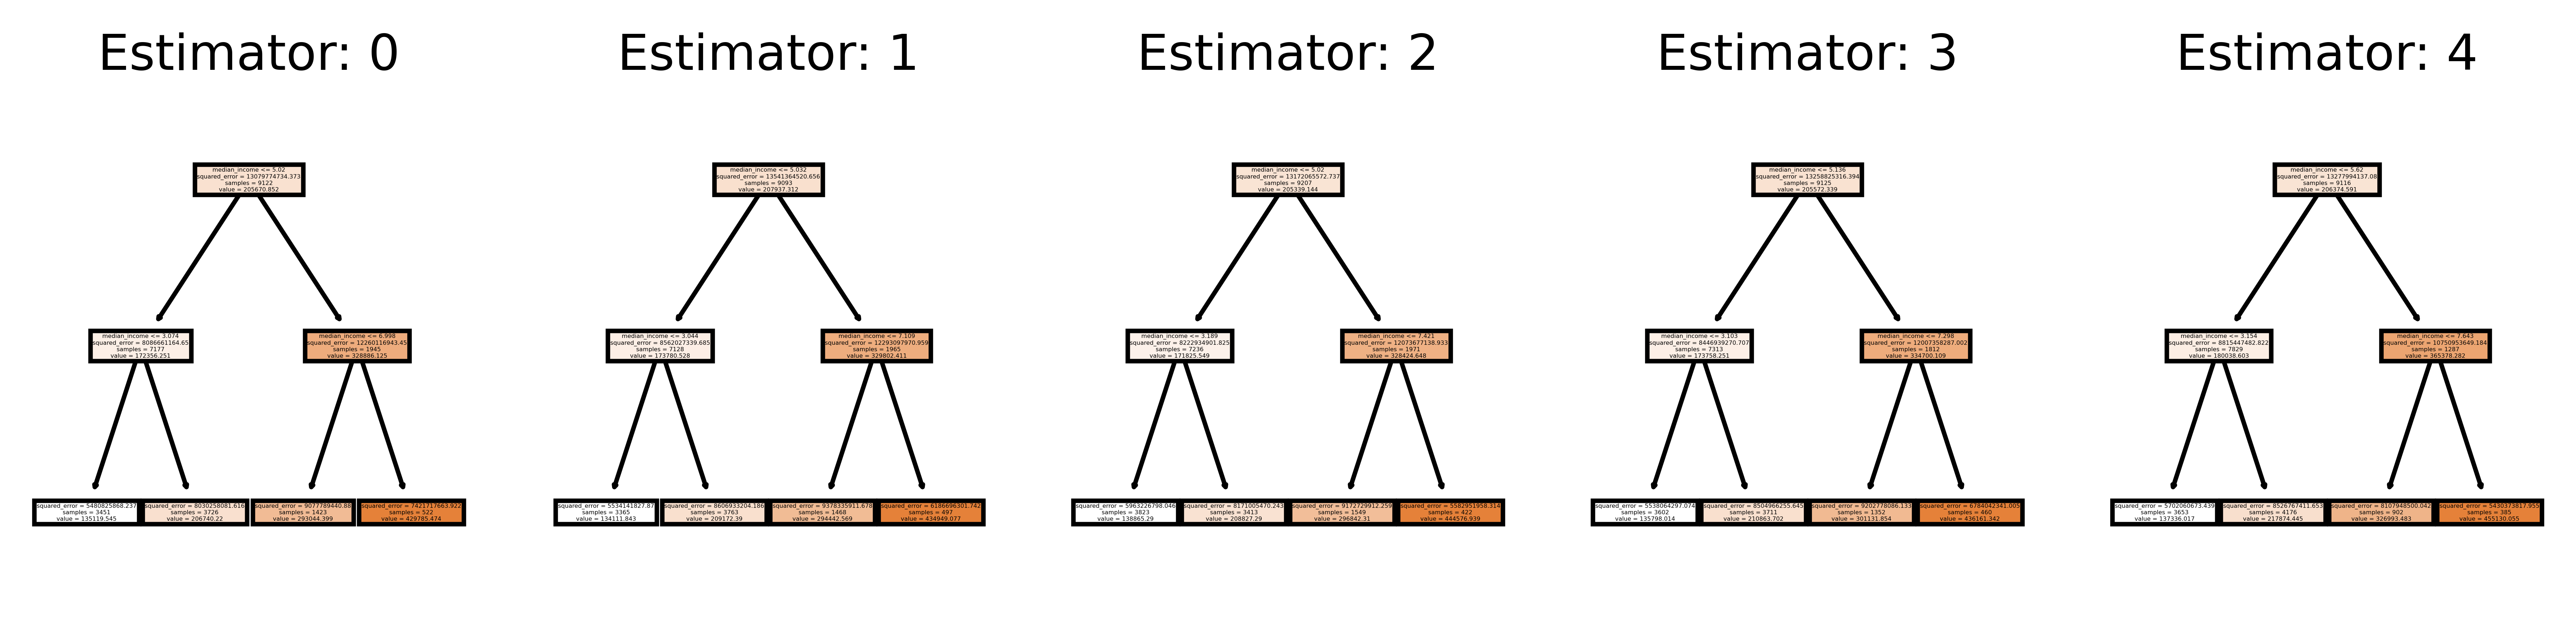

In [ ]:
#fn=data.feature_names
#cn=data.target_names
fig, axes = plt.subplots(nrows = 1,ncols = 5,figsize = (10,2), dpi=900)
for index in range(0, 5):
    plot_tree(arvores.estimators_[index], feature_names = x_treino.columns, filled = True, ax = axes[index])
    axes[index].set_title('Estimator: ' + str(index), fontsize = 11)

plt.show()

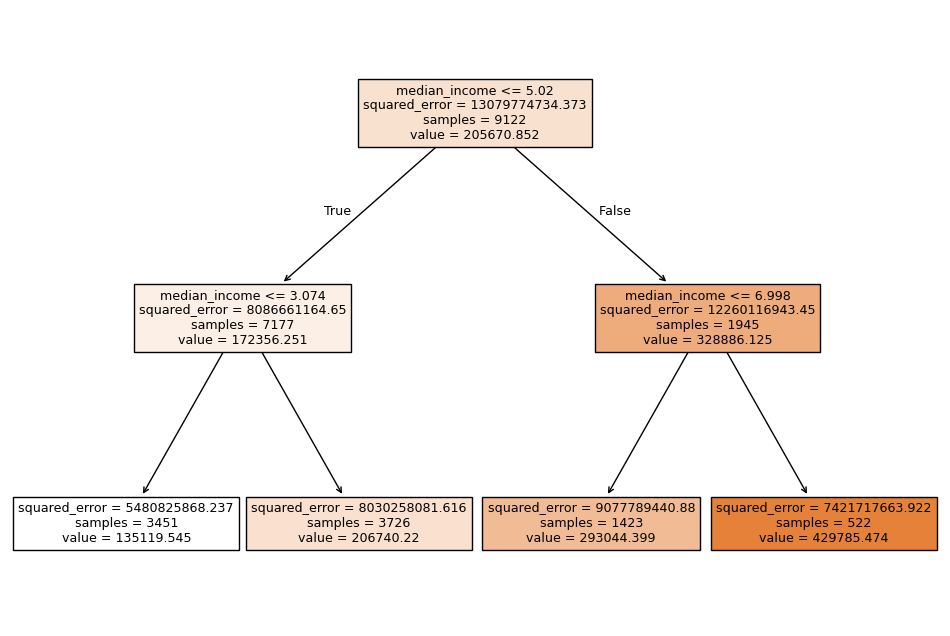

In [51]:
plt.figure(figsize=(12,8))
plot_tree(arvores.estimators_[0], feature_names = x_treino.columns, filled = True)
plt.show()

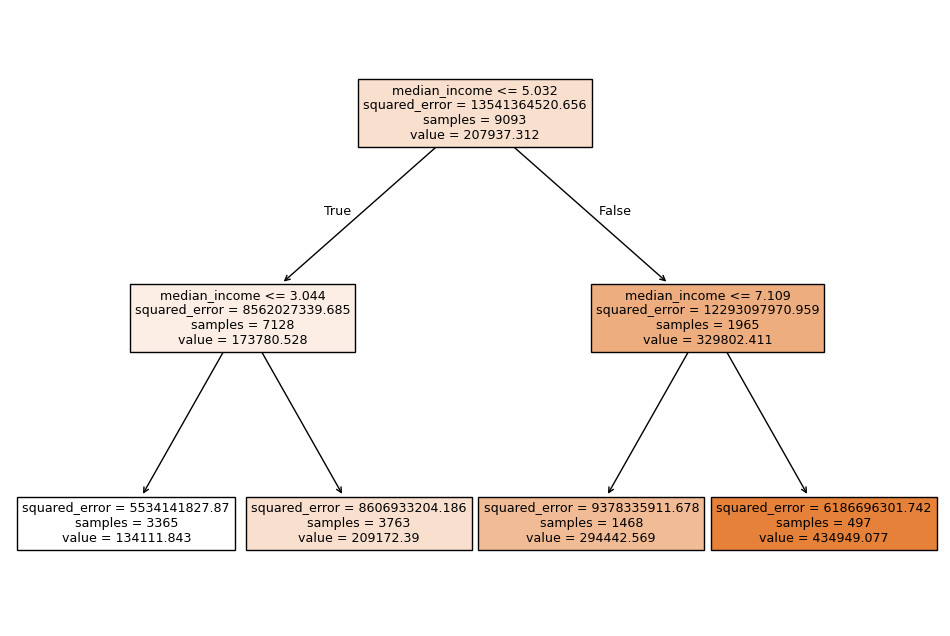

In [52]:
plt.figure(figsize=(12,8))
plot_tree(arvores.estimators_[1], feature_names = x_treino.columns, filled = True)
plt.show()

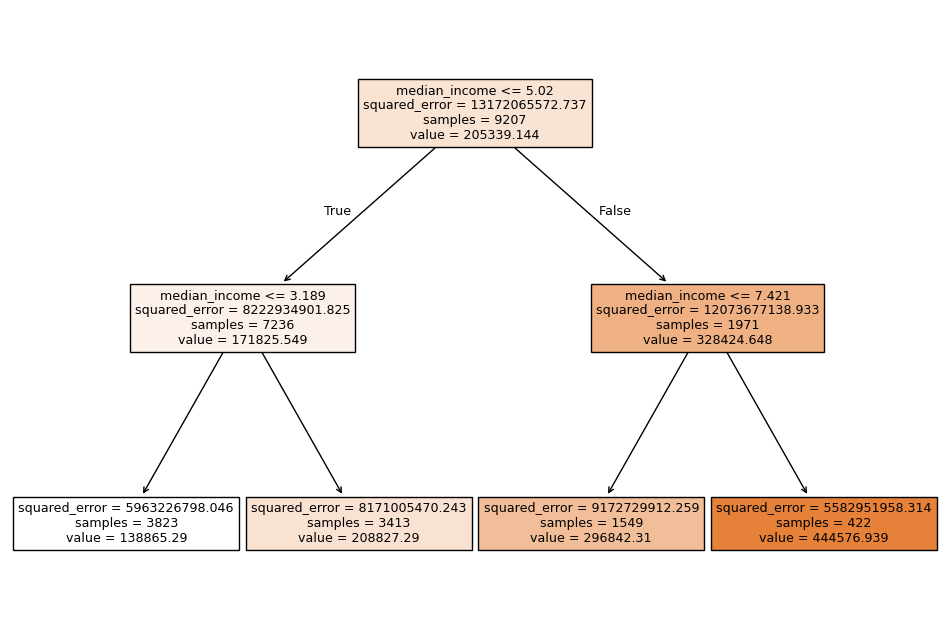

In [53]:
plt.figure(figsize=(12,8))
plot_tree(arvores.estimators_[2], feature_names = x_treino.columns, filled = True)
plt.show()

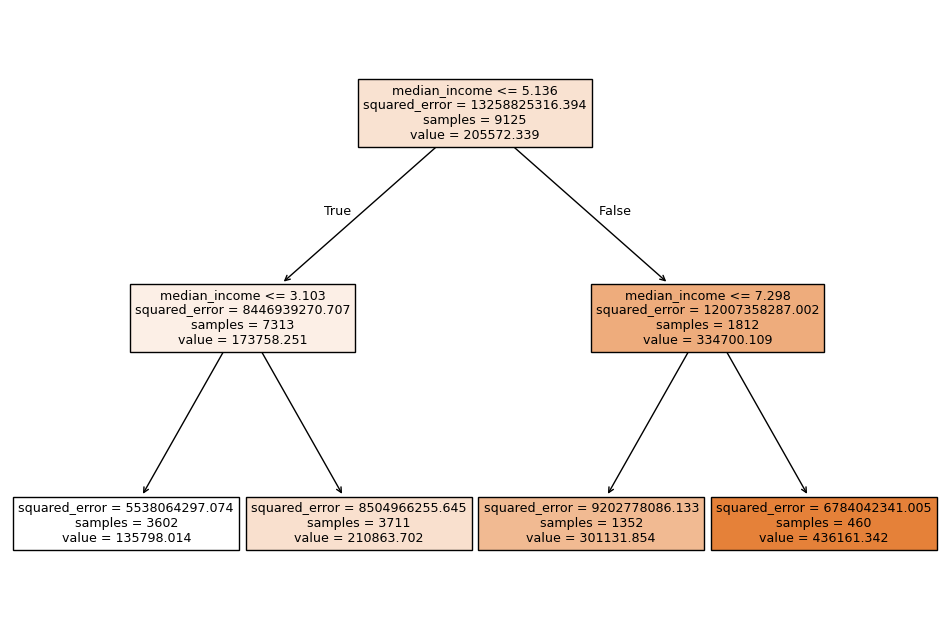

In [54]:
plt.figure(figsize=(12,8))
plot_tree(arvores.estimators_[3], feature_names = x_treino.columns, filled = True)
plt.show()

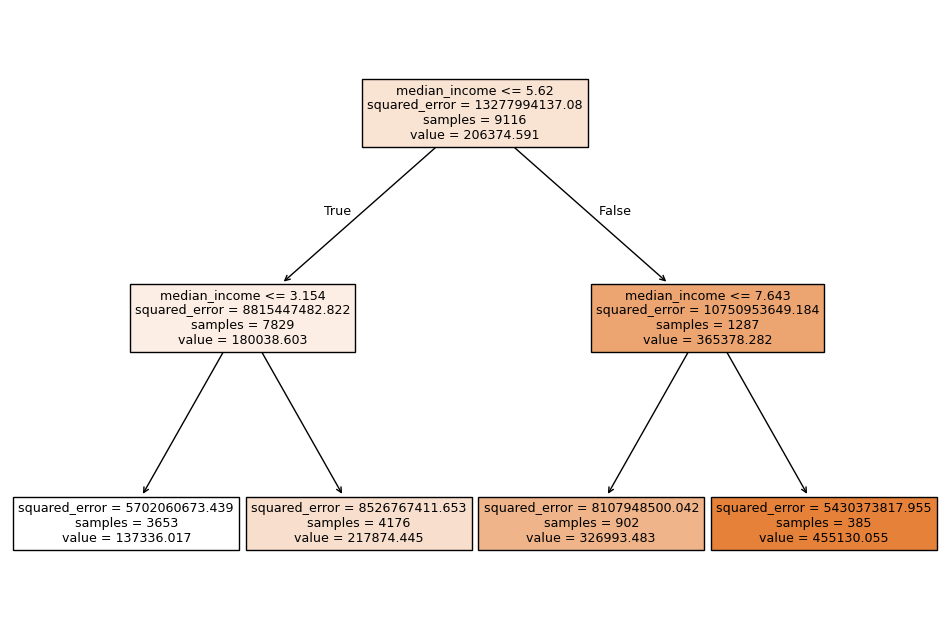

In [55]:
plt.figure(figsize=(12,8))
plot_tree(arvores.estimators_[4], feature_names = x_treino.columns, filled = True)
plt.show()

In [56]:
# Criar um modelo com 3 nós em cada arvore e utilizando 5 arvores

# Criando o modelo
arvores = RandomForestRegressor(n_estimators = 5, max_depth = 3, random_state = 42, n_jobs = -1)

# Treinando o modelo
arvores.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvores.predict(x_teste)

# Visualizando o MSE
np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(80636.56492535719)

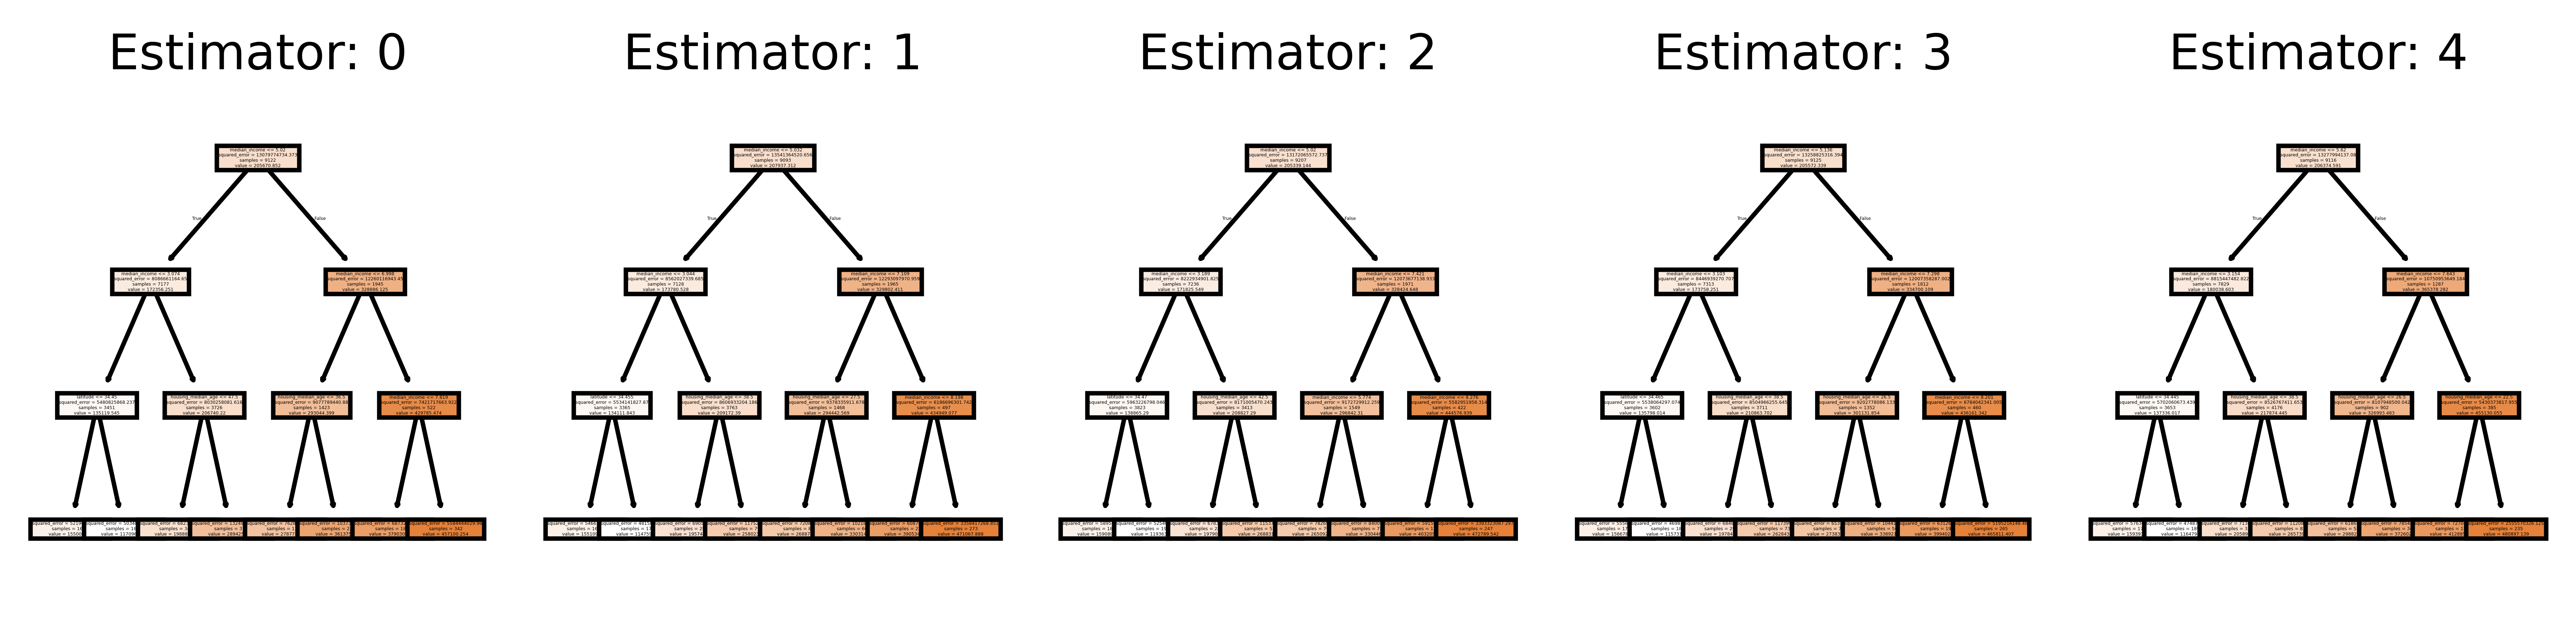

In [57]:
#fn=data.feature_names
#cn=data.target_names
fig, axes = plt.subplots(nrows = 1,ncols = 5,figsize = (10,2), dpi=900)
for index in range(0, 5):
    plot_tree(arvores.estimators_[index], feature_names = x_treino.columns, filled = True, ax = axes[index])
    axes[index].set_title('Estimator: ' + str(index), fontsize = 11)

plt.show()

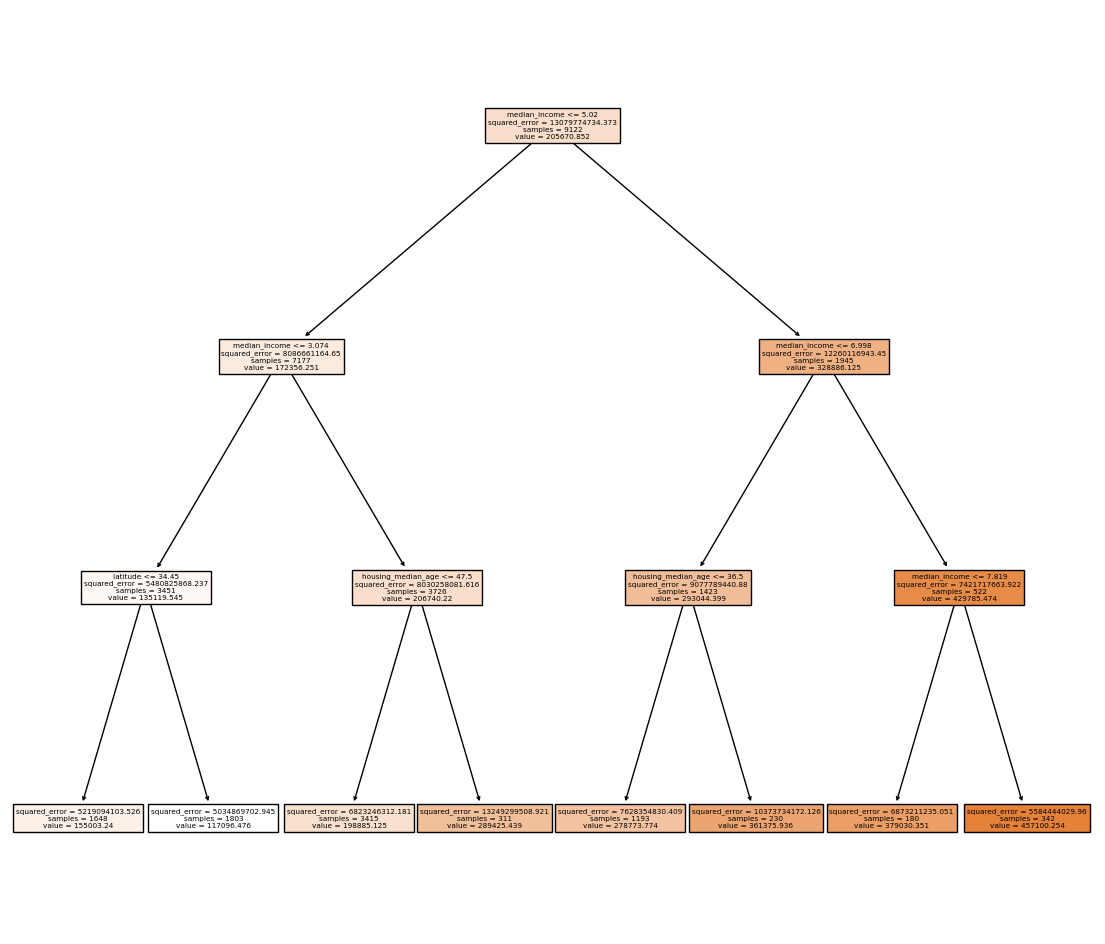

In [ ]:
plt.figure(figsize=(14,12))
plot_tree(arvores.estimators_[0], feature_names = x_treino.columns, filled = True)
plt.show()

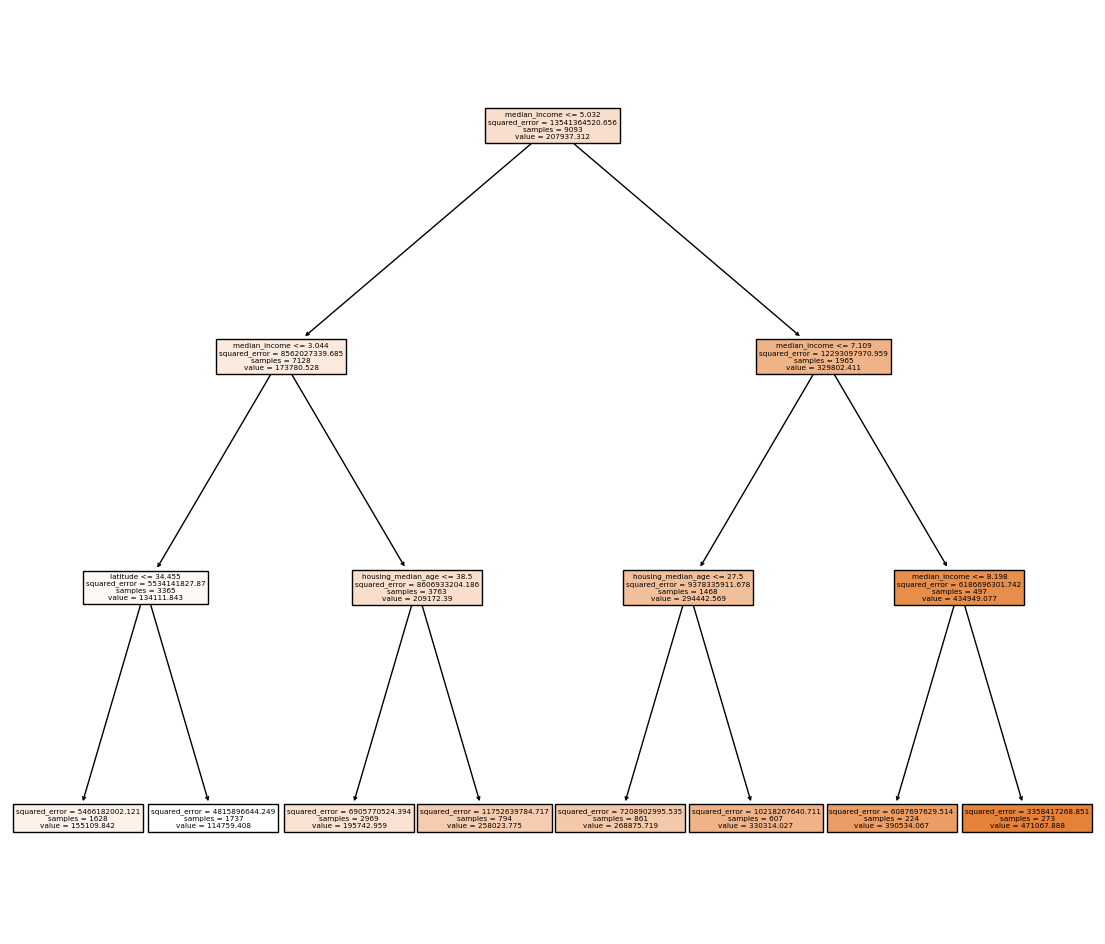

In [ ]:
plt.figure(figsize=(14,12))
plot_tree(arvores.estimators_[1], feature_names = x_treino.columns, filled = True)
plt.show()

# Resumo
<p>O Random forest ira aplicar a aleatoriedade nas variaveis e nas observações do dataset
<p>Ele irá fazer uma amostra com reposição (bootstrap sampling / baggin)  
<p>E pra cada arvore ele irá utilizar um conjunto de dados...
<p>No final ele irá fazer uma média com o resultado de todas as arvores pra gerar o resultado final